# Random Forest Regression for Airbnb Price Prediction

## Objective

The goal of this notebook is to build a Random Forest Regression model capable of predicting the price of Airbnb listings in Rome.

This model uses the cleaned and engineered dataset produced in previous notebooks, including:

- Listing characteristics
- Host-related features
- Geographic features
- Availability indicators
- Review-based aggregated features

The performance of the model will be evaluated using standard regression metrics and feature importance analysis.



In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Loading the Dataset

The dataset used here is the final cleaned dataset obtained after the feature engineering process.

The target variable is:

- price

All other variables will be considered candidate predictors.

In [2]:
df = pd.read_csv("../data/final_dataset.csv")

df.head()

,id,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster,review_count,avg_review_length,latest_review_date,days_since_latest_review
0,2737,57.0,41.871360,12.482150,Private Room,Private room,1,1.0,1.0,1.5,...,False,False,False,False,2.252726,3.0,5.0,51.800000,2015-05-08,3783.0
1,11834,110.0,41.895447,12.491181,Apartment,Entire home/apt,2,1.0,1.0,1.0,...,False,False,False,False,0.588865,4.0,284.0,76.450704,2025-07-05,72.0
2,12398,124.0,41.925820,12.469280,Apartment,Entire home/apt,6,2.0,3.0,1.0,...,False,False,False,False,4.389669,1.0,85.0,84.658824,2025-08-01,45.0
3,19965,162.0,41.908230,12.452930,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,3.824847,1.0,178.0,44.410112,2025-08-05,41.0
4,19967,150.0,41.908283,12.452617,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,3.850102,1.0,46.0,33.673913,2024-07-19,423.0


## 2. Initial Dataset Inspection

Before preparing the data for modeling, we inspect the dataset structure, variable types and missing values.

In [3]:
print(df.shape)

df.info()

(33564, 64)
<class 'pandas.DataFrame'>
RangeIndex: 33564 entries, 0 to 33563
Data columns (total 64 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   id                                                 33564 non-null  int64  
 1   price                                              33564 non-null  float64
 2   latitude                                           33564 non-null  float64
 3   longitude                                          33564 non-null  float64
 4   property_type                                      33564 non-null  str    
 5   room_type                                          33564 non-null  str    
 6   accommodates                                       33564 non-null  int64  
 7   bedrooms                                           33564 non-null  float64
 8   beds                                               33564 non-null  float64
 9   bathr

## 3. Data Preprocessing


### 3.1 Missing Value Treatment

Remaining missing numerical values are replaced using median imputation.

In [4]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

last_review               4295
latest_review_date        4295
location_cluster          3406
id                           0
property_type                0
room_type                    0
latitude                     0
price                        0
beds                         0
bathrooms                    0
host_is_superhost            0
host_response_rate           0
host_acceptance_rate         0
review_scores_rating         0
accommodates                 0
longitude                    0
review_scores_location       0
review_scores_value          0
reviews_per_month            0
number_of_reviews            0
dtype: int64

In [5]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

### 3.2 Date Feature Engineering

Date variables cannot be directly used by machine learning algorithms.

We therefore transform review dates into numerical variables that capture review recency and temporal patterns.

#### Latest Review Date Components

In [6]:
df["latest_review_date"] = pd.to_datetime(
    df["latest_review_date"],
    errors="coerce"
)

df["latest_review_year"] = (
    df["latest_review_date"].dt.year
)

df["latest_review_month"] = (
    df["latest_review_date"].dt.month
)

df["latest_review_day"] = (
    df["latest_review_date"].dt.day
)

df.drop(
    columns=["latest_review_date"],
    inplace=True
)

#### Review Recency

In [7]:
df["days_since_last_review"] = (
    pd.Timestamp.today() - pd.to_datetime(df["last_review"])
).dt.days

In [8]:
df.drop(
    columns=["last_review"],
    inplace=True
)

### 3.3 Identifier Removal
Unique identifiers do not provide predictive information for price estimation and may introduce unnecessary noise into the model.
Therefore, the listing identifier is removed before training.

In [9]:
# adjust to dataset
columns_to_drop = [
    "id"
]

existing_cols = [c for c in columns_to_drop if c in df.columns]

df = df.drop(columns=existing_cols)

### 3.4 Categorical Encoding
The remaining categorical variables are transformed into dummy variables using one-hot encoding.
The first category is dropped to avoid redundant information.

In [10]:
df = pd.get_dummies(
    df,
    columns=[
        "property_type",
        "room_type",
        "instant_bookable"
    ],
    drop_first=True
)

In [11]:
bool_cols = df.select_dtypes(
    include="bool"
).columns

df[bool_cols] = df[bool_cols].astype(int)

## 4. Target Variable Analysis

Before training the model, we inspect the distribution of the target variable.

Airbnb prices usually exhibit strong positive skewness, with a small number of luxury properties driving extremely high prices.

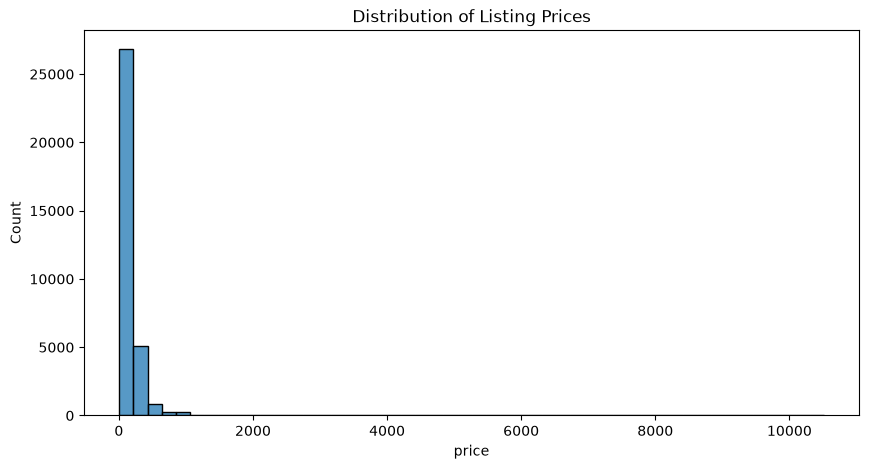

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of Listing Prices")
plt.show()

### 4.1 Outlier Treatment

Extreme prices may disproportionately influence model training.

To reduce the effect of atypical luxury listings, observations below the 1st percentile and above the 99th percentile are removed.

In [ ]:
#outlier treatment
q1 = df["price"].quantile(0.01)
q99 = df["price"].quantile(0.99)

df = df[
    (df["price"] >= q1) &
    (df["price"] <= q99)
]

print(df.shape)

(32902, 73)


## 5. Feature Preparation for Modeling

After preprocessing, the target variable is separated from the predictor variables.

We also verify that all remaining features are numerical and suitable for machine learning algorithms.

#### Numerical Feature Validation

Before model training, we verify that all remaining predictors are numerical and compatible with the Random Forest algorithm.

In [ ]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

[]


In [ ]:
df = df.dropna(
    subset=["price"]
)

X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]

### 5.1 Final Modeling Dataset Validation

Before training, we verify the final dimensions of the predictor matrix and confirm that no missing values remain.

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", X.shape[1])

print("Remaining missing values:", df.isnull().sum().sum())

X shape: (32902, 72)
y shape: (32902,)
Number of features: 72
Remaining missing values: 16480


## 6. Train-Test Split

The dataset is divided into training and testing subsets.

- 80% Training
- 20% Testing

The testing set remains unseen during model training and is used to evaluate generalization performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(26321, 72)
(6581, 72)


## 7. Baseline Random Forest Model

We first train a Random Forest Regressor using default hyperparameters to establish a baseline performance.

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 46.77
RMSE: 81.39
R²  : 0.5467


## 8. Hyperparameter Optimization

Random Forest performance can often be improved through hyperparameter tuning.

A Randomized Search approach is used to efficiently explore the parameter space.

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   9.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   9.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  10.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  10.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  14.4s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  29.7s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  29.8s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  29.7s
[CV] END max_depth=None, max_featur

### Best Hyperparameters

The Randomized Search procedure identifies the combination of parameters that minimizes prediction error during cross-validation.

In [ ]:
rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20}

In [ ]:
best_rf = rf_random.best_estimator_

pred_best = best_rf.predict(X_test)

## 9. Model Evaluation 

In [ ]:
mae = mean_absolute_error(y_test, pred_best)

rmse = np.sqrt(mean_squared_error(y_test, pred_best))

r2 = r2_score(y_test, pred_best)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 45.46
RMSE: 79.47
R²  : 0.5679


In [ ]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 120.94


The optimized Random Forest model is evaluated using MAE, RMSE and R².
Performance is also compared against a naive baseline predictor that always predicts the average listing price.

### Interpretation

The Random Forest model substantially improves upon the baseline predictor, reducing RMSE from 120.94 to 79.47.

An R² of approximately 0.57 indicates that the model explains around 57% of the variability in Airbnb listing prices.

Considering the complexity and heterogeneity of Airbnb pricing behavior, this represents a solid predictive performance for a first machine learning model.

## 10. Feature Importance Analysis

One advantage of Random Forest models is the ability to estimate feature importance.

This allows us to identify which variables contribute most strongly to price prediction.

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(20)

,feature,importance
5,bathrooms,0.084969
3,bedrooms,0.077537
2,accommodates,0.075391
52,distance_to_colosseum,0.054845
1,longitude,0.051948
0,latitude,0.042744
37,neighbourhood_cleansed_I Centro Storico,0.040297
4,beds,0.034148
11,review_scores_location,0.029460
36,demand_proxy,0.028064


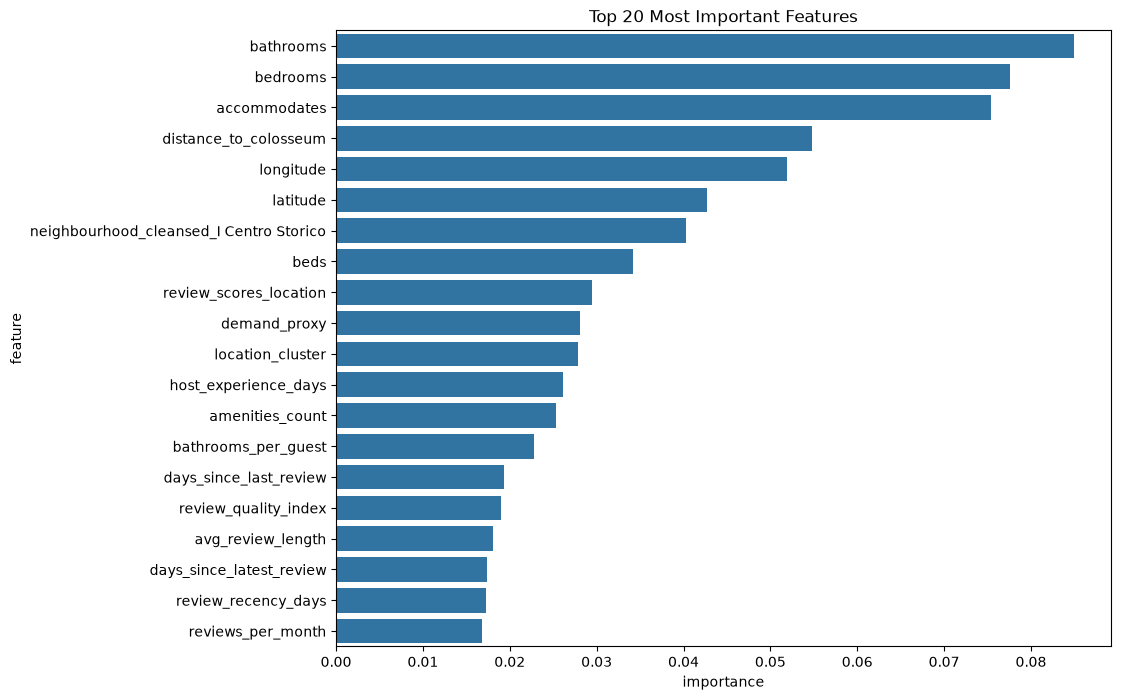

In [ ]:
# visualization 
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Most Important Features")
plt.show()

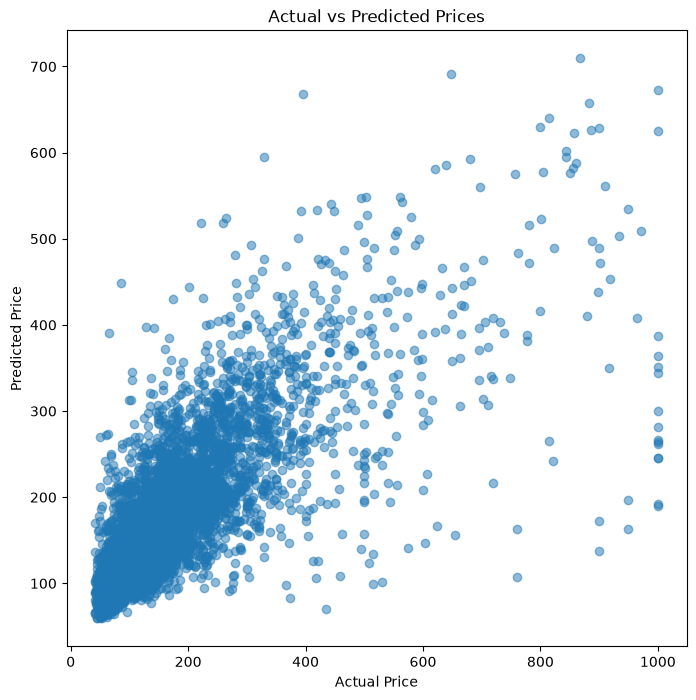

In [ ]:
# predicted vs actual prices
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

## 11. Conclusions

The objective of this project was to predict Airbnb listing prices in Rome using a Random Forest Regression model trained on engineered listing, host, review, availability, and geographic features.

### Key Findings

- The optimized Random Forest model achieved:
  - MAE = 45.46
  - RMSE = 79.47
  - R² = 0.568

- The model outperformed the baseline predictor, reducing RMSE from 120.94 to 79.47.

- The model explains approximately 57% of the variability in Airbnb listing prices, indicating that the engineered features capture a significant portion of the factors influencing pricing decisions.

- Property size and capacity were among the strongest predictors of price. Bathrooms, bedrooms, accommodates, and beds consistently ranked among the rest of the most important features.

- Geographic location played a major role in pricing. Distance to the Colosseum, latitude, longitude, neighborhood indicators, and location clusters all appeared among the most influential predictors.

- Demand and reputation indicators also contributed to price prediction. Variables such as review scores, demand_proxy, host_experience_days, review_quality_index, and review activity metrics provided additional predictive value.

### Most Important Features

The top predictors identified by the model were:

1. bathrooms
2. bedrooms
3. accommodates
4. distance_to_colosseum
5. longitude
6. latitude
7. neighbourhood_cleansed_I Centro Storico
8. beds
9. review_scores_location
10. demand_proxy

These results suggest that listing size, centrality, neighborhood characteristics, and guest perception are key drivers of Airbnb prices in Rome.

### Limitations and Future Work

Although the model achieved strong performance, approximately 43% of price variability remains unexplained. Future improvements could include:

- Sentiment analysis of review text.
- External tourism indicators and event data.
- Seasonal demand features derived from tourism statistics.
- Comparison with Gradient Boosting, XGBoost, or LightGBM models.
- More advanced geographic features based on distance to major attractions and transportation hubs.

Overall, the Random Forest model provides a solid predictive baseline and demonstrates that feature engineering substantially improves the ability to explain Airbnb pricing behavior in Rome.